In [60]:
import sqlite3
import pandas as pd
import re
from pathlib import Path


REPO_ROOT = Path("/Users/neo/Projects/temple")
RUNS_CSV = REPO_ROOT / "experiments/cnv_reversion/manifests/runs.csv"


def decode_value(x):
    return float(x.replace("p", "."))


def parse_scenario_id(scenario_id):
    # example:
    # al__control__mp_0p001983__rev_0p05__cost_0p0005
    arm, policy, rest = scenario_id.split("__", 2)

    m = re.search(
        r"mp_(.*?)__rev_(.*?)__cost_(.*)$",
        rest
    )
    if not m:
        raise ValueError(f"Cannot parse scenario_id: {scenario_id}")

    return {
        "arm": arm,
        "policy": policy,
        "mutation_rate": decode_value(m.group(1)),
        "reversion_multiplier": decode_value(m.group(2)),
        "cnv_cost": decode_value(m.group(3)),
    }


def extract_output_path(command):
    # command looks like:
    # ./build/bin/MalaSim -i ... -o experiments/cnv_reversion/outputs/.../ -j 0
    m = re.search(r"\s-o\s+(\S+)\s+-j\s+(\d+)", command)
    if not m:
        raise ValueError(f"Cannot parse command: {command}")

    output_rel = m.group(1)
    job = int(m.group(2))
    return output_rel, job


def extract_gene_copies(genotype_name):
    """
    Extract:
    - pfmdr1_copies from the first 2-letter + number block after ||||
      Example: ||||YF1|| or ||||NF2||

    - pfplasmepsin_copies from the final pipe-number suffix
      Example: ...CRA|1 or ...YRA|2

    Supports copy numbers > 2.
    """

    pfmdr1_match = re.search(r"\|\|\|\|[A-Z]{2}(\d+)\|\|", genotype_name)
    if not pfmdr1_match:
        raise ValueError(f"Cannot parse pfmdr1 copies from: {genotype_name}")

    pfplas_match = re.search(r"\|(\d+)$", genotype_name)
    if not pfplas_match:
        raise ValueError(f"Cannot parse pfplasmepsin copies from: {genotype_name}")

    return {
        "pfmdr1_copies": int(pfmdr1_match.group(1)),
        "pfplasmepsin_copies": int(pfplas_match.group(1)),
    }


def load_one_db(db_path):
    conn = sqlite3.connect(db_path)

    geno = pd.read_sql_query("""
        SELECT monthly_data_id, location_id, genome_id, occurrences
        FROM monthly_genome_data_cell
    """, conn)

    time = pd.read_sql_query("""
        SELECT id, days_elapsed
        FROM monthly_data
    """, conn)

    genotype = pd.read_sql_query("""
        SELECT id, name
        FROM genotype
    """, conn)

    conn.close()

    df = geno.merge(time, left_on="monthly_data_id", right_on="id")
    df = df.merge(genotype, left_on="genome_id", right_on="id")

    copy_df = df["name"].apply(extract_gene_copies).apply(pd.Series)
    df = pd.concat([df, copy_df], axis=1)

    agg = (
        df.groupby([
            "days_elapsed",
            "location_id",
            "pfmdr1_copies",
            "pfplasmepsin_copies",
        ])["occurrences"]
        .sum()
        .reset_index()
    )

    agg["total"] = (
        agg.groupby(["days_elapsed", "location_id"])["occurrences"]
        .transform("sum")
    )

    agg["freq"] = agg["occurrences"] / agg["total"]

    return agg[
        [
            "days_elapsed",
            "location_id",
            "pfmdr1_copies",
            "pfplasmepsin_copies",
            "occurrences",
            "total",
            "freq",
        ]
    ]
def sqlite_has_table(db_path, table_name):
    conn = sqlite3.connect(db_path)
    try:
        result = pd.read_sql_query(
            """
            SELECT name
            FROM sqlite_master
            WHERE type = 'table'
              AND name = ?
            """,
            conn,
            params=(table_name,),
        )
    finally:
        conn.close()

    return not result.empty

def build_all_copy_number_table(
    runs_csv=RUNS_CSV,
    repo_root=REPO_ROOT,
    arm_filter=("al", "as_mq", "dha_ppq"),
    policy_filter=("control", "withdrawal"),
):
    runs = pd.read_csv(runs_csv)

    meta = pd.DataFrame([
        {
            **parse_scenario_id(row.scenario_id),
            "scenario_id": row.scenario_id,
            "command": row.command,
        }
        for row in runs.itertuples(index=False)
    ])

    parsed = runs["command"].apply(extract_output_path)
    runs["output_rel"] = [x[0] for x in parsed]
    runs["job"] = [x[1] for x in parsed]

    runs = runs.merge(
        meta.drop(columns=["command"]).drop_duplicates(),
        on="scenario_id",
        how="left"
    )

    runs = runs[
        runs["arm"].isin(arm_filter)
        & runs["policy"].isin(policy_filter)
    ].copy()

    all_parts = []

    required_tables = [
        "monthly_genome_data_cell",
        "monthly_data",
        "genotype",
    ]

    for row in runs.itertuples(index=False):
        db_path = repo_root / row.output_rel / f"monthly_data_{row.job}.db"

        if not db_path.exists():
            print(f"Missing: {db_path}")
            continue

        missing_tables = [
            table for table in required_tables
            if not sqlite_has_table(db_path, table)
        ]

        if missing_tables:
            print(f"Skipping DB with missing tables: {db_path}")
            print(f"  Missing: {', '.join(missing_tables)}")
            continue

        try:
            one = load_one_db(db_path)
        except (sqlite3.OperationalError, sqlite3.DatabaseError) as e:
            print(f"Skipping unreadable DB: {db_path}")
            print(f"  Reason: {e}")
            continue

        one["scenario_id"] = row.scenario_id
        one["job"] = row.job
        one["arm"] = row.arm
        one["policy"] = row.policy
        one["mutation_rate"] = row.mutation_rate
        one["reversion_multiplier"] = row.reversion_multiplier
        one["cnv_cost"] = row.cnv_cost

        all_parts.append(one)

    if not all_parts:
        raise RuntimeError("No DB files loaded.")

    return pd.concat(all_parts, ignore_index=True)

In [61]:
all_cnv = build_all_copy_number_table()
all_cnv.to_csv("all_cnv_frequencies.csv", index=False)

Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/withdrawal/mp_0p005__rev_0p4__cost_0p005/monthly_data_5.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/withdrawal/mp_0p005__rev_0p4__cost_0p005/monthly_data_6.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/withdrawal/mp_0p005__rev_0p4__cost_0p005/monthly_data_7.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/withdrawal/mp_0p005__rev_0p4__cost_0p005/monthly_data_8.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/withdrawal/mp_0p005__rev_0p4__cost_0p005/monthly_data_9.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/withdrawal/mp_0p005__rev_0p4__cost_0p01/monthly_data_0.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/withdrawal/mp_0p005__rev_0p4__cost_0p01/monthly_data_1.db
Missing: /Users/neo/Projects/temple/experiments/cnv_reversion/outputs/al/withd

In [62]:
print(f"Loaded {len(all_cnv)} rows of CNV frequency data.")
print(f"{all_cnv.scenario_id.nunique()} unique scenario_ids.")
all_cnv.head()

Loaded 326733 rows of CNV frequency data.
119 unique scenario_ids.


,days_elapsed,location_id,pfmdr1_copies,pfplasmepsin_copies,occurrences,total,freq,scenario_id,job,arm,policy,mutation_rate,reversion_multiplier,cnv_cost
0,0,0,1,1,99375,99375,1.000000,al__control__mp_0p001983__rev_0__cost_0p0005,0,al,control,0.001983,0.0,0.0005
1,31,0,1,1,104483,104774,0.997223,al__control__mp_0p001983__rev_0__cost_0p0005,0,al,control,0.001983,0.0,0.0005
2,31,0,2,1,291,104774,0.002777,al__control__mp_0p001983__rev_0__cost_0p0005,0,al,control,0.001983,0.0,0.0005
3,60,0,1,1,130511,131185,0.994862,al__control__mp_0p001983__rev_0__cost_0p0005,0,al,control,0.001983,0.0,0.0005
4,60,0,2,1,674,131185,0.005138,al__control__mp_0p001983__rev_0__cost_0p0005,0,al,control,0.001983,0.0,0.0005


In [63]:
import matplotlib.pyplot as plt


def plot_copy_number_trajectories(
    all_cnv,
    arm="al",
    policy="control",
    mutation_rate=0.001983,
    cnv_cost=0.0005,
    location_id=0,
    gene="pfmdr1",
    copies=2,
    fallback_to_all_copies=True,
):
    copy_col_map = {
        "pfmdr1": "pfmdr1_copies",
        "mdr1": "pfmdr1_copies",
        "pfplasmepsin": "pfplasmepsin_copies",
        "plasmepsin": "pfplasmepsin_copies",
        "plas": "pfplasmepsin_copies",
    }

    if gene not in copy_col_map:
        raise ValueError(
            f"Unknown gene: {gene}. Use 'pfmdr1' or 'pfplasmepsin'."
        )

    copy_col = copy_col_map[gene]

    # Filter scenario-level data first.
    sub = all_cnv[
        (all_cnv["arm"] == arm)
        & (all_cnv["policy"] == policy)
        & (all_cnv["mutation_rate"] == mutation_rate)
        & (all_cnv["cnv_cost"] == cnv_cost)
        & (all_cnv["location_id"] == location_id)
    ].copy()

    if sub.empty:
        print("No data for requested scenario.")
        print("Available combinations:")

        available = (
            all_cnv[
                ["arm", "policy", "mutation_rate", "cnv_cost", "location_id"]
            ]
            .drop_duplicates()
            .sort_values(["arm", "policy", "mutation_rate", "cnv_cost", "location_id"])
        )

        display(available.head(30))
        return None

    # Convert joint frequency table to marginal frequency for selected gene.
    group_cols = [
        "scenario_id",
        "job",
        "arm",
        "policy",
        "mutation_rate",
        "reversion_multiplier",
        "cnv_cost",
        "days_elapsed",
        "location_id",
        copy_col,
    ]

    marginal = (
        sub.groupby(group_cols)["occurrences"]
        .sum()
        .reset_index()
    )

    marginal["total"] = (
        marginal
        .groupby([
            "scenario_id",
            "job",
            "days_elapsed",
            "location_id",
        ])["occurrences"]
        .transform("sum")
    )

    marginal["freq"] = marginal["occurrences"] / marginal["total"]

    available_copies = sorted(marginal[copy_col].dropna().unique())

    if copies not in available_copies:
        print(
            f"No data for {gene} {copies} copies. "
            f"Available copy numbers: {available_copies}"
        )

        if not fallback_to_all_copies:
            return None

        print("Plotting all available copy numbers instead.")
        copies_to_plot = available_copies
    else:
        copies_to_plot = [copies]

    gene_label_map = {
        "pfmdr1_copies": "pfmdr1",
        "pfplasmepsin_copies": "pfplasmepsin",
    }

    gene_label = gene_label_map[copy_col]

    fig, ax = plt.subplots(figsize=(10, 5))

    for copy_number in copies_to_plot:
        m = marginal[marginal[copy_col] == copy_number].copy()

        summary = (
            m.groupby(["reversion_multiplier", "days_elapsed"])["freq"]
            .agg(
                median="median",
                q10=lambda x: x.quantile(0.10),
                q90=lambda x: x.quantile(0.90),
            )
            .reset_index()
        )

        for rev in sorted(summary["reversion_multiplier"].unique()):
            s = summary[summary["reversion_multiplier"] == rev]

            if len(copies_to_plot) == 1:
                label = f"rev={rev:g}"
            else:
                label = f"{copy_number} copies, rev={rev:g}"

            ax.plot(
                s["days_elapsed"],
                s["median"],
                linewidth=2,
                label=label,
            )

            ax.fill_between(
                s["days_elapsed"],
                s["q10"],
                s["q90"],
                alpha=0.12,
            )

    if len(copies_to_plot) == 1:
        copy_title = f"{copies_to_plot[0]}-copy"
        y_label = f"{gene_label} {copies_to_plot[0]}-copy frequency"
    else:
        copy_title = "copy-number"
        y_label = f"{gene_label} copy-number frequency"

    ax.set_title(
        f"{gene_label} {copy_title} frequency over time | "
        f"{arm}, {policy}, mp={mutation_rate:g}, "
        f"cost={cnv_cost:g}, loc={location_id}"
    )

    ax.set_xlabel("Days elapsed")
    ax.set_ylabel(y_label)
    ax.legend(title="Trajectory", fontsize=8)

    plt.tight_layout()
    plt.show()

    return marginal

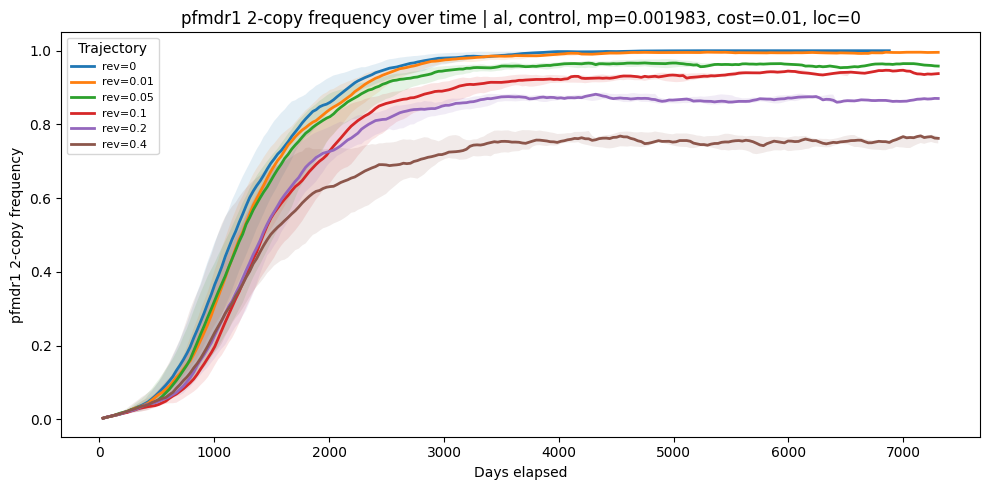

,scenario_id,job,arm,policy,mutation_rate,reversion_multiplier,cnv_cost,days_elapsed,location_id,pfmdr1_copies,occurrences,total,freq
0,al__control__mp_0p001983__rev_0__cost_0p01,0,al,control,0.001983,0.0,0.01,0,0,1,99671,99671,1.000000
1,al__control__mp_0p001983__rev_0__cost_0p01,0,al,control,0.001983,0.0,0.01,31,0,1,104210,104493,0.997292
2,al__control__mp_0p001983__rev_0__cost_0p01,0,al,control,0.001983,0.0,0.01,31,0,2,283,104493,0.002708
3,al__control__mp_0p001983__rev_0__cost_0p01,0,al,control,0.001983,0.0,0.01,60,0,1,130858,131480,0.995269
4,al__control__mp_0p001983__rev_0__cost_0p01,0,al,control,0.001983,0.0,0.01,60,0,2,622,131480,0.004731
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21171,al__control__mp_0p001983__rev_0p4__cost_0p01,9,al,control,0.001983,0.4,0.01,7244,0,2,318075,414792,0.766830
21172,al__control__mp_0p001983__rev_0p4__cost_0p01,9,al,control,0.001983,0.4,0.01,7274,0,1,98728,416514,0.237034
21173,al__control__mp_0p001983__rev_0p4__cost_0p01,9,al,control,0.001983,0.4,0.01,7274,0,2,317786,416514,0.762966
21174,al__control__mp_0p001983__rev_0p4__cost_0p01,9,al,control,0.001983,0.4,0.01,7305,0,1,99280,417593,0.237743


In [66]:
plot_copy_number_trajectories(
    all_cnv,
    arm="al",
    policy="control",
    mutation_rate=0.001983,
    cnv_cost=0.01,
    location_id=0,
    gene="pfmdr1",
    copies=2,
)

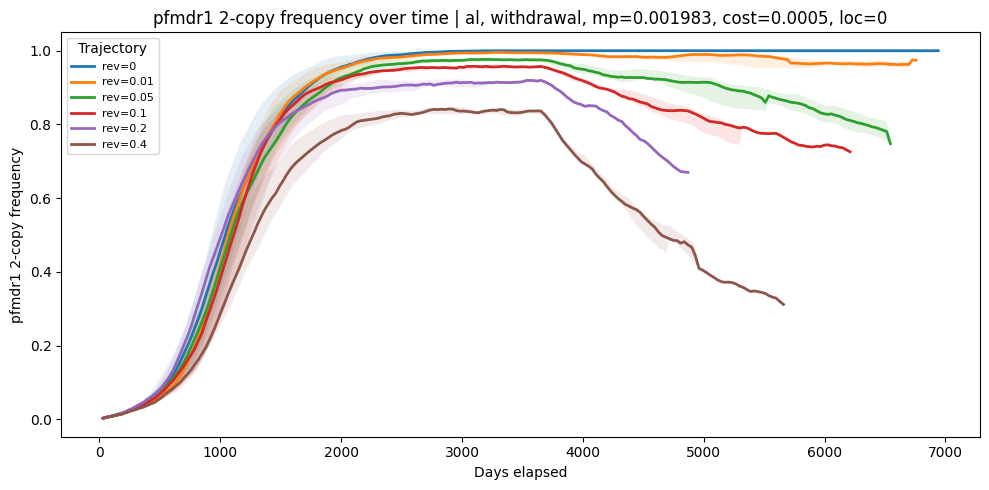

,scenario_id,job,arm,policy,mutation_rate,reversion_multiplier,cnv_cost,days_elapsed,location_id,pfmdr1_copies,occurrences,total,freq
0,al__withdrawal__mp_0p001983__rev_0__cost_0p0005,0,al,withdrawal,0.001983,0.0,0.0005,0,0,1,99657,99657,1.000000
1,al__withdrawal__mp_0p001983__rev_0__cost_0p0005,0,al,withdrawal,0.001983,0.0,0.0005,31,0,1,103539,103802,0.997466
2,al__withdrawal__mp_0p001983__rev_0__cost_0p0005,0,al,withdrawal,0.001983,0.0,0.0005,31,0,2,263,103802,0.002534
3,al__withdrawal__mp_0p001983__rev_0__cost_0p0005,0,al,withdrawal,0.001983,0.0,0.0005,60,0,1,130133,130825,0.994710
4,al__withdrawal__mp_0p001983__rev_0__cost_0p0005,0,al,withdrawal,0.001983,0.0,0.0005,60,0,2,692,130825,0.005290
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15578,al__withdrawal__mp_0p001983__rev_0p4__cost_0p0005,9,al,withdrawal,0.001983,0.4,0.0005,4627,0,2,122544,273777,0.447605
15579,al__withdrawal__mp_0p001983__rev_0p4__cost_0p0005,9,al,withdrawal,0.001983,0.4,0.0005,4657,0,1,154629,278377,0.555466
15580,al__withdrawal__mp_0p001983__rev_0p4__cost_0p0005,9,al,withdrawal,0.001983,0.4,0.0005,4657,0,2,123748,278377,0.444534
15581,al__withdrawal__mp_0p001983__rev_0p4__cost_0p0005,9,al,withdrawal,0.001983,0.4,0.0005,4688,0,1,159350,281808,0.565456


In [68]:
plot_copy_number_trajectories(
    all_cnv,
    arm="al",
    policy="withdrawal",
    mutation_rate=0.001983,
    cnv_cost=0.0005,
    location_id=0,
    gene="pfmdr1",
    copies=2,
)

In [69]:
plot_copy_number_trajectories(
    all_cnv,
    arm="as_mq",
    policy="control",
    mutation_rate=0.001983,
    cnv_cost=0.0005,
    location_id=0,
    gene="pfmdr1",
    copies=2,
)

No data for requested scenario.
Available combinations:


,arm,policy,mutation_rate,cnv_cost,location_id
0,al,control,0.001983,0.0005,0
3088,al,control,0.001983,0.0010,0
6031,al,control,0.001983,0.0050,0
9333,al,control,0.001983,0.0100,0
83731,al,control,0.005000,0.0005,0
87194,al,control,0.005000,0.0010,0
90711,al,control,0.005000,0.0050,0
93845,al,control,0.005000,0.0100,0
160951,al,control,0.010000,0.0005,0
163375,al,control,0.010000,0.0010,0


In [56]:
plot_copy_number_trajectories(
    all_cnv,
    arm="dha_ppq",
    policy="control",
    mutation_rate=0.001983,
    cnv_cost=0.0005,
    location_id=0,
    gene="pfplasmepsin",
    copies=2,
)

No data for requested scenario.
Available combinations:


,arm,policy,mutation_rate,cnv_cost,location_id
0,al,control,0.001983,0.0005,0
3671,al,control,0.001983,0.0010,0
7297,al,control,0.001983,0.0050,0
11028,al,control,0.001983,0.0100,0
111355,al,control,0.005000,0.0005,0
114907,al,control,0.005000,0.0010,0
118368,al,control,0.005000,0.0050,0
122037,al,control,0.005000,0.0100,0
161536,al,control,0.010000,0.0005,0
162301,al,control,0.010000,0.0010,0
